This script includes:
1. Datasets= 
i. icu_stays = contains the stay id, subject id, intime, outtime and readmission(target variable)
ii. icu_timeseries = contains the hourly vital signs and other features of each stay id.
iii. ICU_OUTPUT_EVENTS = contains additional features

2. Preprocessing of the datasets which includes only the first 24 hours data of each stay_id 

3. Model Training using Random Forest

4. Model evaluation

5. Plots and visualizations for the influencing features, learning curve

6. Readmission likelihood of specific stay id.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV, learning_curve, StratifiedKFold, cross_val_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.metrics import make_scorer, f1_score

In [2]:
# Load data
# Change the paths accordingly
icu_stays = pd.read_feather(r'processed/icustays_20240512.feather')
icu_timeseries = pd.read_feather(r'processed/icu_timeseries_features_0M_0ed859c799267d4ae737f8814d52726d_20240512.feather')
ICU_OUTPUT_EVENTS = pd.read_feather(r'processed/icu_outputevents_0M_0ed859c799267d4ae737f8814d52726d_20240512.feather')

In [3]:
# Convert datetime columns
icu_stays['icu_intime'] = pd.to_datetime(icu_stays['icu_intime'])
icu_stays['icu_outtime'] = pd.to_datetime(icu_stays['icu_outtime'])

#Rename icu_stay_id in 'icu_stays' dataset to stay_id before merging
icu_stays.rename(columns={'icu_stay_id': 'stay_id'}, inplace=True)
icu_stays['stay_id'] = icu_stays['stay_id'].astype(int)

icu_stays.head()

,subject_id,hadm_id,stay_id,first_careunit,icu_intime,icu_outtime,icu_los,hours_until_readmission,will_be_readmitted,hours_to_readmission,stay_is_readmission
0,10018328,23786647,31269608,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,NaN,False,NaN,False
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,NaN,False,NaN,False
2,10020187,26842957,32554129,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,NaN,False,NaN,False
3,10012853,27882036,31338022,Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,NaN,False,NaN,False
4,10020740,25826145,32145159,Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,NaN,False,NaN,False


In [4]:
#Create a 'readmitted' column to represent readmission depending on the 'hours_until_readmission' column
icu_stays['readmitted'] = icu_stays['hours_until_readmission'].apply(lambda x: 1 if x <= 720 else 0)
icu_stays['readmitted'] = icu_stays['readmitted'].fillna(0).astype(int)

#only keep the necessary columns in icu_stays dataset
icu_stays = icu_stays[['subject_id', 'stay_id', 'readmitted', 'icu_intime', 'icu_outtime']]
icu_stays.head()

,subject_id,stay_id,readmitted,icu_intime,icu_outtime
0,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21
1,10020187,37509585,0,2169-01-15 04:56:00,2169-01-20 15:47:50
2,10020187,32554129,0,2170-02-24 18:18:46,2170-02-25 15:15:26
3,10012853,31338022,0,2176-11-26 02:34:49,2176-11-29 20:58:54
4,10020740,32145159,0,2150-06-03 20:12:32,2150-06-04 21:05:58


In [5]:
icu_timeseries.head()

,abs_event_time,stay_id,Activity / Mobility (JH-HLM),Apnea Interval,Arterial Blood Pressure Alarm - High,Arterial Blood Pressure Alarm - Low,Arterial Blood Pressure diastolic,Arterial Blood Pressure mean,Arterial Blood Pressure systolic,Current Dyspnea Assessment,...,RDW-SD,Red Blood Cells,Sodium,"Sodium, Whole Blood",Temperature,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2
0,1970-01-01 01:00:00,30057454,NaN,NaN,NaN,NaN,64.800000,75.0,96.800000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1970-01-01 02:00:00,30057454,NaN,NaN,NaN,NaN,62.333333,72.0,93.333333,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,NaN,NaN,NaN
2,1970-01-01 03:00:00,30057454,NaN,NaN,NaN,NaN,64.000000,76.0,99.000000,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,45.0,7.4,76.0
3,1970-01-01 04:00:00,30057454,NaN,NaN,NaN,NaN,67.000000,78.0,102.000000,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,45.0,7.4,76.0
4,1970-01-01 05:00:00,30057454,NaN,NaN,NaN,NaN,67.000000,79.0,105.000000,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,45.0,7.4,76.0


In [6]:
# Preprocess 'abs_event_time' in icu_timeseries to match with the icu_intime of icu_stays
icu_timeseries['abs_event_time'] = pd.to_datetime(icu_timeseries['abs_event_time'])

# Adjust abs_event_time to start from icu_intime for each stay_id
icu_timeseries = icu_timeseries.merge(icu_stays[['stay_id', 'icu_intime']], on='stay_id', how='left')

# Generate the correct abs_event_time starting from icu_intime
icu_timeseries['abs_event_time'] = icu_timeseries.groupby('stay_id').apply(
    lambda df: df['icu_intime'] + pd.to_timedelta(np.arange(len(df)), unit='H')
).reset_index(level=0, drop=True)

icu_timeseries['time_since_icu_intime'] = (icu_timeseries['abs_event_time'] - icu_timeseries['icu_intime']).dt.total_seconds() / 3600.0
icu_timeseries['event_day'] = icu_timeseries['abs_event_time'].dt.day
icu_timeseries['event_month'] = icu_timeseries['abs_event_time'].dt.month
icu_timeseries['event_weekday'] = icu_timeseries['abs_event_time'].dt.weekday
icu_timeseries.drop(columns=['icu_intime'], inplace=True)
icu_timeseries

/tmp/ipykernel_1950237/2032354407.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  lambda df: df['icu_intime'] + pd.to_timedelta(np.arange(len(df)), unit='H')
/tmp/ipykernel_1950237/2032354407.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  icu_timeseries['abs_event_time'] = icu_timeseries.groupby('stay_id').apply(


,abs_event_time,stay_id,Activity / Mobility (JH-HLM),Apnea Interval,Arterial Blood Pressure Alarm - High,Arterial Blood Pressure Alarm - Low,Arterial Blood Pressure diastolic,Arterial Blood Pressure mean,Arterial Blood Pressure systolic,Current Dyspnea Assessment,...,Temperature,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2,time_since_icu_intime,event_day,event_month,event_weekday
0,2171-11-14 10:06:41,30057454,NaN,NaN,NaN,NaN,64.800000,75.0,96.800000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,14,11,3
1,2171-11-14 11:06:41,30057454,NaN,NaN,NaN,NaN,62.333333,72.0,93.333333,NaN,...,NaN,45.0,12.7,NaN,NaN,NaN,1.0,14,11,3
2,2171-11-14 12:06:41,30057454,NaN,NaN,NaN,NaN,64.000000,76.0,99.000000,NaN,...,NaN,45.0,12.7,45.0,7.4,76.0,2.0,14,11,3
3,2171-11-14 13:06:41,30057454,NaN,NaN,NaN,NaN,67.000000,78.0,102.000000,NaN,...,NaN,45.0,12.7,45.0,7.4,76.0,3.0,14,11,3
4,2171-11-14 14:06:41,30057454,NaN,NaN,NaN,NaN,67.000000,79.0,105.000000,NaN,...,NaN,45.0,12.7,45.0,7.4,76.0,4.0,14,11,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2911,2147-12-31 04:33:00,39880770,1.0,60.0,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,19.0,31,12,6
2912,2147-12-31 05:33:00,39880770,1.0,60.0,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,20.0,31,12,6
2913,2147-12-31 06:33:00,39880770,1.0,60.0,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,21.0,31,12,6
2914,2147-12-31 07:33:00,39880770,1.0,60.0,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,22.0,31,12,6


In [7]:
ICU_OUTPUT_EVENTS.head()

,stay_id,urine_last_1d
0,30057454,1621
1,30101877,1857
2,30425410,1070
3,30458995,1760
4,30585761,2010


In [8]:
# Merge the datasets
merge = pd.merge(icu_stays, icu_timeseries, on='stay_id')
merge_final = pd.merge(merge, ICU_OUTPUT_EVENTS, on='stay_id').drop_duplicates()

# Drop subject_id
merge_final = merge_final.drop(columns=['subject_id'])
merge_final.head()

# Check for duplicates in the merged DataFrame
duplicates = merge_final.duplicated().sum()
print(f"Number of duplicate rows in the merged DataFrame: {duplicates}")

# Drop duplicate rows if any
if duplicates > 0:
    merge_final = merge_final.drop_duplicates()
    print("Duplicates dropped.")

Number of duplicate rows in the merged DataFrame: 0


In [9]:
merge_final.shape

(2879, 113)

In [10]:
# Prepare data for model training
X = merge_final.drop(columns=['readmitted'])
y = merge_final['readmitted'].astype(bool)

# Split data into train and test sets with time-based splitting
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Further split the training set into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

In [11]:
# Check class distributions
print("Class distribution in training set:\n", y_train.value_counts())
print("Class distribution in validation set:\n", y_val.value_counts())
print("Class distribution in test set:\n", y_test.value_counts())

Class distribution in training set:
 readmitted
False    1458
True      222
Name: count, dtype: int64
Class distribution in validation set:
 readmitted
False    625
True      95
Name: count, dtype: int64
Class distribution in test set:
 readmitted
False    368
True     111
Name: count, dtype: int64


In [12]:
# Function to calculate the percentage of NaN values in each column
def nan_percentage(df):
    return df.isna().mean().round(4) * 100

# Function to print columns with NaN values if any
def print_columns_with_nan(df, df_name):
    nan_columns = df.columns[df.isna().any()].tolist()
    if nan_columns:
        print(f"Columns with NaN values in {df_name} after imputation: {nan_columns}")
    else:
        print(f"No columns with NaN values in {df_name} after imputation.")

# Identify numerical and categorical columns
numerical_columns = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()

# Print percentage of NaN values before imputation
print("Percentage of NaN values in X_train before imputation:\n", nan_percentage(X_train))
print("Percentage of NaN values in X_val before imputation:\n", nan_percentage(X_val))
print("Percentage of NaN values in X_test before imputation:\n", nan_percentage(X_test))



Percentage of NaN values in X_train before imputation:
 stay_id                          0.00
icu_intime                       0.00
icu_outtime                      0.00
abs_event_time                   0.00
Activity / Mobility (JH-HLM)    57.86
                                ...  
time_since_icu_intime            0.00
event_day                        0.00
event_month                      0.00
event_weekday                    0.00
urine_last_1d                    0.00
Length: 112, dtype: float64
Percentage of NaN values in X_val before imputation:
 stay_id                          0.00
icu_intime                       0.00
icu_outtime                      0.00
abs_event_time                   0.00
Activity / Mobility (JH-HLM)    60.42
                                ...  
time_since_icu_intime            0.00
event_day                        0.00
event_month                      0.00
event_weekday                    0.00
urine_last_1d                    0.00
Length: 112, dtype: float6

In [13]:
# Impute missing values
print("Imputing missing values...")
imputer = IterativeImputer(random_state=42)
X_train_imputed = imputer.fit_transform(X_train[numerical_columns])
X_val_imputed = imputer.transform(X_val[numerical_columns])
X_test_imputed = imputer.transform(X_test[numerical_columns])

# Convert imputed data back to DataFrame
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=numerical_columns)
X_val_imputed_df = pd.DataFrame(X_val_imputed, columns=numerical_columns)
X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=numerical_columns)

# Print percentage of NaN values after imputation
print("Percentage of NaN values in X_train after imputation:\n", nan_percentage(X_train_imputed_df))
print("Percentage of NaN values in X_val after imputation:\n", nan_percentage(X_val_imputed_df))
print("Percentage of NaN values in X_test after imputation:\n", nan_percentage(X_test_imputed_df))


Imputing missing values...
Percentage of NaN values in X_train after imputation:
 stay_id                                 0.0
Activity / Mobility (JH-HLM)            0.0
Apnea Interval                          0.0
Arterial Blood Pressure Alarm - High    0.0
Arterial Blood Pressure Alarm - Low     0.0
                                       ... 
pCO2                                    0.0
pH                                      0.0
pO2                                     0.0
time_since_icu_intime                   0.0
urine_last_1d                           0.0
Length: 106, dtype: float64
Percentage of NaN values in X_val after imputation:
 stay_id                                 0.0
Activity / Mobility (JH-HLM)            0.0
Apnea Interval                          0.0
Arterial Blood Pressure Alarm - High    0.0
Arterial Blood Pressure Alarm - Low     0.0
                                       ... 
pCO2                                    0.0
pH                                      0.0
p

In [14]:
# Print columns with NaN values after imputation
print_columns_with_nan(X_train_imputed_df, "X_train")
print_columns_with_nan(X_val_imputed_df, "X_val")
print_columns_with_nan(X_test_imputed_df, "X_test")

No columns with NaN values in X_train after imputation.
No columns with NaN values in X_val after imputation.
No columns with NaN values in X_test after imputation.


In [15]:
# Encode categorical columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[categorical_columns])
X_train_encoded = encoder.transform(X_train[categorical_columns])
X_val_encoded = encoder.transform(X_val[categorical_columns])
X_test_encoded = encoder.transform(X_test[categorical_columns])

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(categorical_columns))
X_val_encoded_df = pd.DataFrame(X_val_encoded, columns=encoder.get_feature_names_out(categorical_columns))
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(categorical_columns))

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed_df)
X_val_scaled = scaler.transform(X_val_imputed_df)
X_test_scaled = scaler.transform(X_test_imputed_df)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_imputed_df.columns)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val_imputed_df.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_imputed_df.columns)

# Combine scaled and encoded features
X_train_processed = pd.concat([X_train_scaled_df, X_train_encoded_df], axis=1)
X_val_processed = pd.concat([X_val_scaled_df, X_val_encoded_df], axis=1)
X_test_processed = pd.concat([X_test_scaled_df, X_test_encoded_df], axis=1)

In [16]:
# Apply SMOTE to handle class imbalance in training data
smote = SMOTE(random_state=42)
X_train_upsampled, y_train_upsampled = smote.fit_resample(X_train_processed, y_train)

# Check class distribution in upsampled training set
print("Class distribution in upsampled training set:\n", pd.Series(y_train_upsampled).value_counts())

# Check if both classes are present in `y_train_upsampled`
if len(np.unique(y_train_upsampled)) != 2:
    raise ValueError("SMOTE did not create both classes in the upsampled training set.")

Class distribution in upsampled training set:
 readmitted
False    1458
True     1458
Name: count, dtype: int64


In [17]:
# Feature Selection using RFECV (Recursive Feature Elimination Cross Validation)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Use StratifiedKFold for RFECV to ensure each fold has both classes
cv = StratifiedKFold(n_splits=5)
rfecv = RFECV(estimator=rf_model, step=1, cv=cv, scoring='roc_auc')
rfecv.fit(X_train_upsampled, y_train_upsampled)

# Select top features
top_features = X_train_processed.columns[rfecv.support_]
print("Number of selected features:", len(top_features))

Number of selected features: 30


In [18]:
# Transform datasets to keep only selected features
X_train_final = X_train_upsampled[top_features]
X_val_final = X_val_processed[top_features]
X_test_final = X_test_processed[top_features]

# Standardize the final selected features
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_val_final_scaled = scaler_final.transform(X_val_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

# Check final shapes
print("Final shapes:")
print("X_train_final_scaled shape:", X_train_final_scaled.shape)
print("X_val_final_scaled shape:", X_val_final_scaled.shape)
print("X_test_final_scaled shape:", X_test_final_scaled.shape)
print("Class distribution in validation set:\n", y_val.value_counts())
print("Class distribution in test set:\n", y_test.value_counts())

Final shapes:
X_train_final_scaled shape: (2916, 30)
X_val_final_scaled shape: (720, 30)
X_test_final_scaled shape: (479, 30)
Class distribution in validation set:
 readmitted
False    625
True      95
Name: count, dtype: int64
Class distribution in test set:
 readmitted
False    368
True     111
Name: count, dtype: int64


In [26]:
# Random Forest Model Training
# Define scoring metric
scoring = make_scorer(roc_auc_score)

# Perform GridSearchCV
print("Performing GridSearchCV...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    n_jobs=-1
)

try:
    grid_search_rf.fit(X_train_final_scaled, y_train_upsampled)
except ValueError as e:
    print("ValueError during GridSearchCV fitting:", e)
    print("Check the data and parameters.")
    raise

print("Best parameters found:", grid_search_rf.best_params_)
print("Best cross validation score found:", grid_search_rf.best_score_)

best_rf_model = grid_search_rf.best_estimator_

Performing GridSearchCV...
Best parameters found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best cross validation score found: 0.9955420609141836


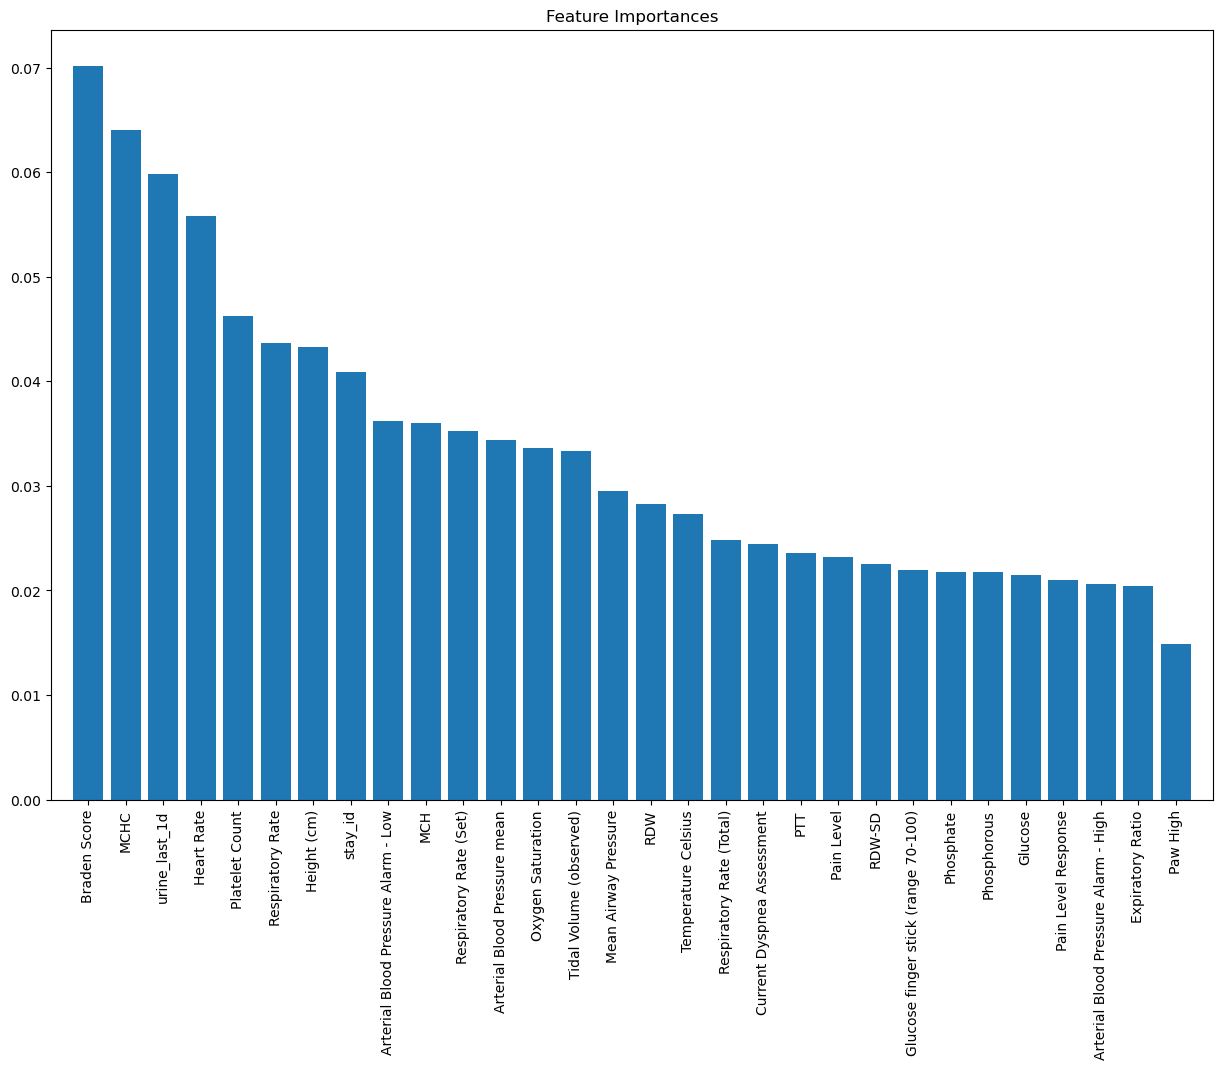

In [27]:
# Plot the feature importances
importances = best_rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(15, 10))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [top_features[i] for i in indices], rotation=90)
plt.xlim([-1, len(importances)])
plt.show()

In [28]:
# Model evaluation
y_val_pred = best_rf_model.predict(X_val_final_scaled)
y_test_pred = best_rf_model.predict(X_test_final_scaled)

# Calculate metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, best_rf_model.predict_proba(X_val_final_scaled)[:, 1])
val_f1 = f1_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test_final_scaled)[:, 1])
test_f1 = f1_score(y_test, y_test_pred)

print("Validation Accuracy:", val_accuracy)
print("Validation ROC AUC:", val_roc_auc)
print("Validation F1 Score:", val_f1)
print("Test Accuracy:", test_accuracy)
print("Test ROC AUC:", test_roc_auc)
print("Test F1 Score:", test_f1)

Validation Accuracy: 0.9875
Validation ROC AUC: 0.999258947368421
Validation F1 Score: 0.9508196721311475
Test Accuracy: 0.8016701461377871
Test ROC AUC: 0.6908538973756364
Test F1 Score: 0.25196850393700787


Confusion Matrix:
 [[368   0]
 [ 95  16]]


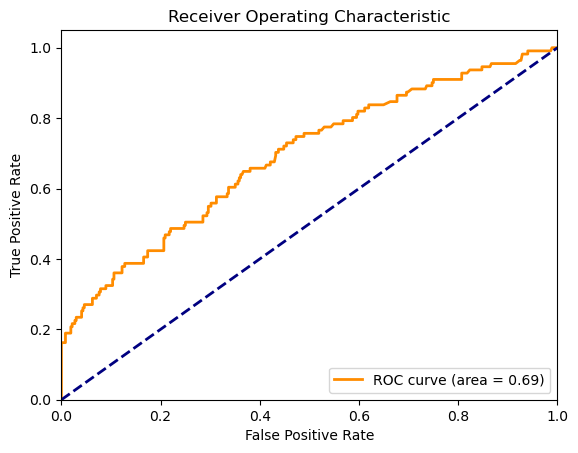

In [29]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", conf_matrix)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_rf_model.predict_proba(X_test_final_scaled)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

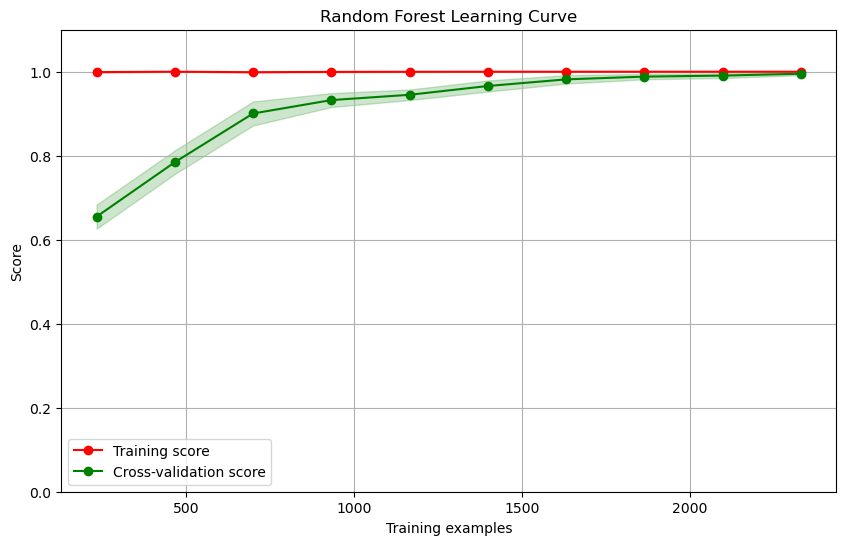

In [30]:
#Learning curve
def plot_learning_curve(estimator, X, y, title="Learning Curve", cv=None, n_jobs=None):
    """
    Plot the learning curve of a model.
    
    Parameters:
    - estimator: The model to evaluate.
    - X: The features.
    - y: The target.
    - title: The title of the plot.
    - cv: Cross-validation splitting strategy.
    - n_jobs: Number of jobs to run in parallel.
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )
    
    # Calculate mean and std deviation for training and test scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # Plot the learning curve
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.ylim(0, 1.1)
    
    # Plot training score
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2, color="r")
    
    # Plot cross-validation score
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2, color="g")
    
    plt.legend(loc="best")
    plt.grid()
    plt.show()
    
    # Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Plot learning curve for the best model
plot_learning_curve(best_rf_model, X_train_final_scaled, y_train_upsampled, title="Random Forest Learning Curve", cv=cv, n_jobs=-1)

Saving the model into a pickle file:

In [ ]:
import pickle

# Objects to be saved
objects_to_save = {
    'best_rf_model': best_rf_model,
    'top_features': top_features,
    'imputer': imputer,
    'encoder': encoder,
    'scaler': scaler,
    'scaler_final': scaler_final,
    'merge_final': merge_final
}

with open('models/final_readmission_model.pkl', 'wb') as f:
    pickle.dump(objects_to_save, f)